# Loan Approval Prediction 
## Objective
Build and evaluate multiple machine learning models to predict loan approval decisions.
This notebook includes model comparison, cross-validation, hyperparameter tuning,
ROC comparison, threshold tuning, overfitting check, and final business insights.


## Import Required Libraries
Import libraries for data processing and modeling.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

## Load Dataset
Load and clean column names.

In [57]:
df = pd.read_csv(r"C:\Users\Shreya\OneDrive\Desktop\WsCubeTech\Data Analytics Mentorship Program\MACHINE-LEARNING\loan_approval_dataset.csv")

df.columns = df.columns.str.strip().str.lower()
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


## Dataset Overview
Check dataset info and missing values.

In [58]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [59]:
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [60]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


## Encoding Categorical Variables

Machine learning models require numerical input.
This step converts categorical variables into numeric format 
using Label Encoding.

This ensures the dataset is fully compatible with sklearn models.


In [61]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


## Target Variable Distribution

This plot shows the distribution of approved and rejected loan applications.
It helps identify whether the dataset is balanced or imbalanced.
Class imbalance can affect model performance and fairness.


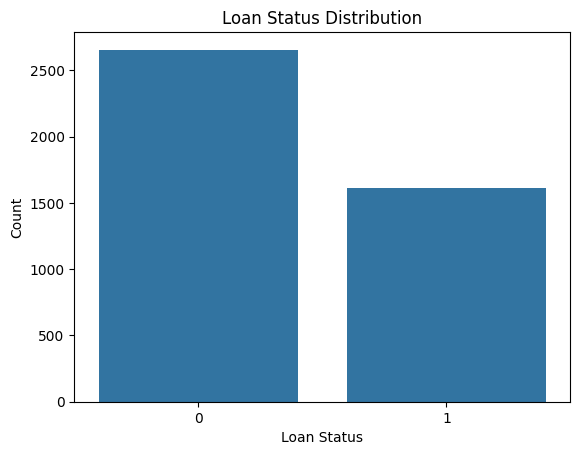

In [62]:
plt.figure()
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

In [63]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


## Income vs Loan Amount Analysis

This scatter plot visualizes the relationship between applicant income 
and requested loan amount. The color indicates loan approval status.

This helps in understanding financial risk patterns.


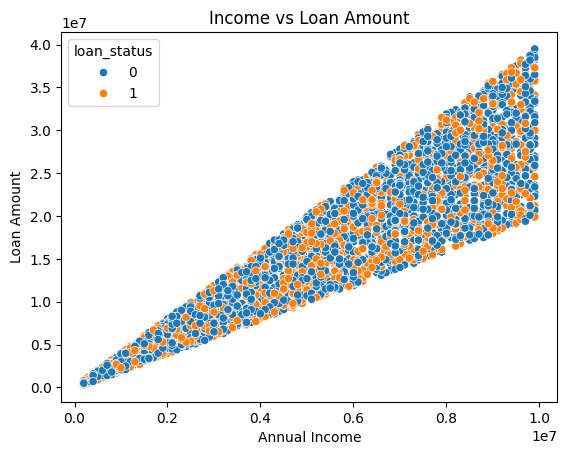

In [64]:
plt.figure()
sns.scatterplot(x='income_annum', y='loan_amount', hue='loan_status', data=df)
plt.title("Income vs Loan Amount")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.show()


## Feature Correlation Heatmap

This heatmap shows correlations between numerical variables.
It helps identify relationships between financial factors 
that may influence loan approval decisions.


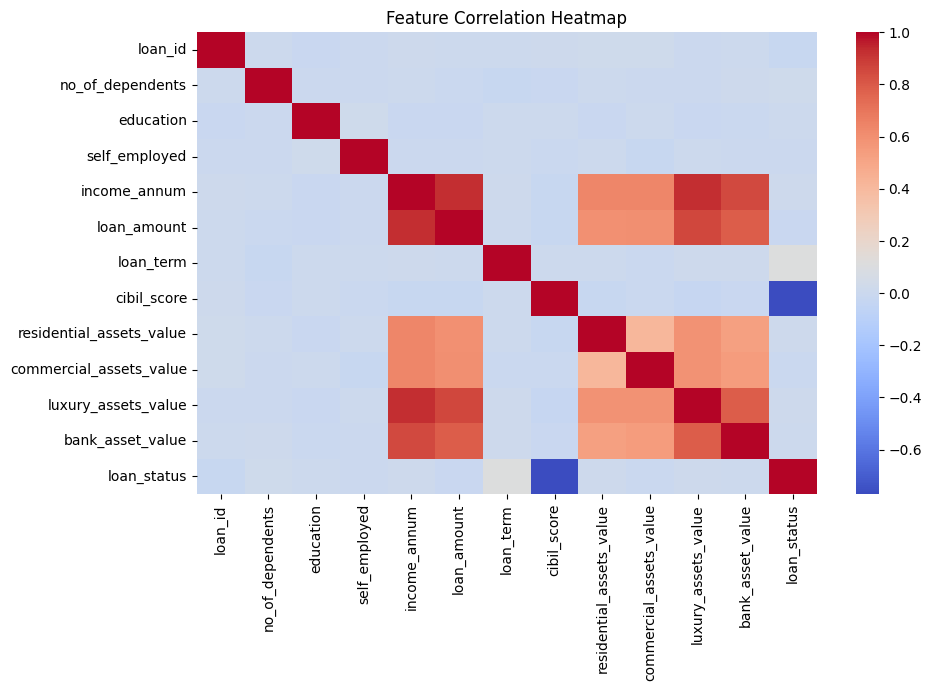

In [65]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


## Train-Test Split
Separate features and target variable.

In [66]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Logistic Train:", lr.score(X_train, y_train))
print("Logistic Test:", lr.score(X_test, y_test))

print("Decision Tree Train:", dt.score(X_train, y_train))
print("Decision Tree Test:", dt.score(X_test, y_test))


Logistic Train: 0.6222547584187409
Logistic Test: 0.6217798594847775
Decision Tree Train: 0.6222547584187409
Decision Tree Test: 0.6217798594847775


C:\Users\Shreya\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Shreya\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\Shreya\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\Shreya\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


## Feature Scaling
Standardize features.

In [67]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train Models
Train Logistic Regression, Decision Tree, and Random Forest.

In [68]:
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.9215456674473068
Decision Tree Accuracy: 0.9754098360655737
Random Forest Accuracy: 0.9800936768149883


## Cross Validation
Check model stability using 5-fold CV

In [69]:
cv_scores = cross_val_score(rf, X_train, y_train, cv=5)
print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.98096633 0.98243045 0.97218155 0.97510981 0.98682284]
Mean CV Accuracy: 0.9795021961932651


## Hyperparameter Tuning
Optimize Random Forest parameters.

In [70]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)
print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_best))

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Tuned Model Accuracy: 0.9812646370023419


## Overfitting Check
Compare training and testing accuracy.

In [71]:
print("Train Accuracy:", best_rf.score(X_train, y_train))
print("Test Accuracy:", best_rf.score(X_test, y_test))

Train Accuracy: 0.9982430453879941
Test Accuracy: 0.9812646370023419


## Precision, Recall, F1 Score
Evaluate detailed classification metrics.

In [72]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       531
           1       0.99      0.96      0.97       323

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



## ROC Curve Comparison
Compare ROC curves and AUC for all models.

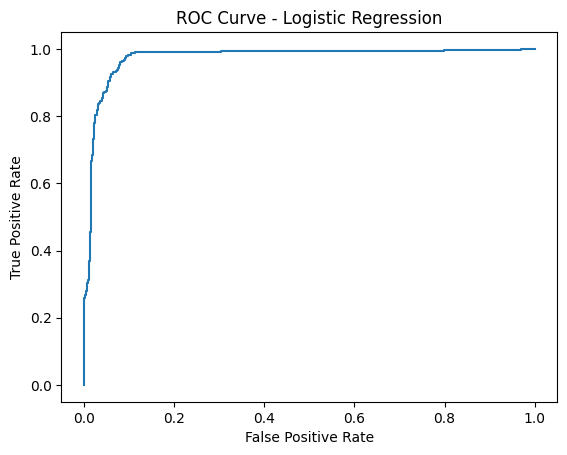

Logistic Regression AUC: 0.97434013748229


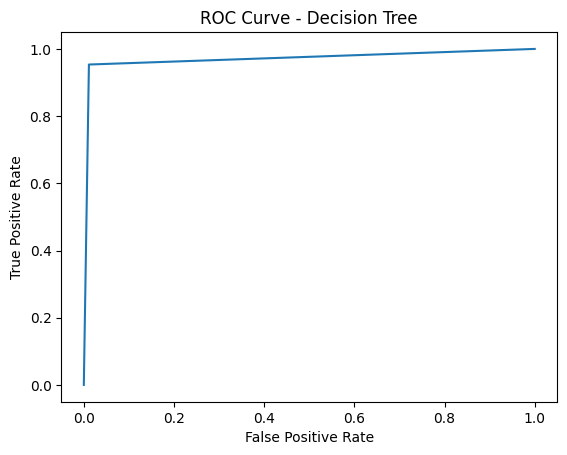

Decision Tree AUC: 0.9711304682443895


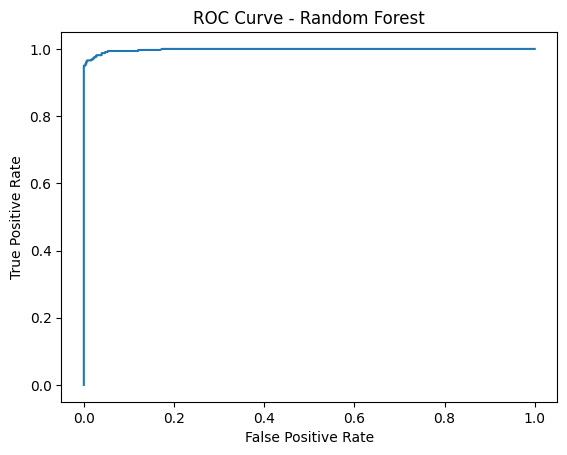

Random Forest AUC: 0.9981050999049635


In [73]:
models = {'Logistic Regression': lr, 'Decision Tree': dt, 'Random Forest': best_rf}

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr)
    plt.title("ROC Curve - " + name)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()
    
    print(name, "AUC:", roc_auc)

## Threshold Tuning
Adjust probability threshold to manage risk level.

In [74]:
y_prob = best_rf.predict_proba(X_test)[:,1]

custom_threshold = 0.6
y_pred_custom = np.where(y_prob > custom_threshold, 1, 0)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       531
           1       1.00      0.94      0.97       323

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854



## Feature Importance Analysis

This graph shows the most influential features affecting
loan approval predictions based on the tuned Random Forest model.

Higher importance indicates stronger influence on model decisions.


In [75]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)



                     Feature  Importance
7                cibil_score    0.806935
6                  loan_term    0.059761
5                loan_amount    0.027067
4               income_annum    0.017531
0                    loan_id    0.016783
10       luxury_assets_value    0.016579
8   residential_assets_value    0.016094
9    commercial_assets_value    0.014914
11          bank_asset_value    0.013808
1           no_of_dependents    0.006614
3              self_employed    0.002285
2                  education    0.001629


Text(0.5, 1.0, 'Feature Importance')

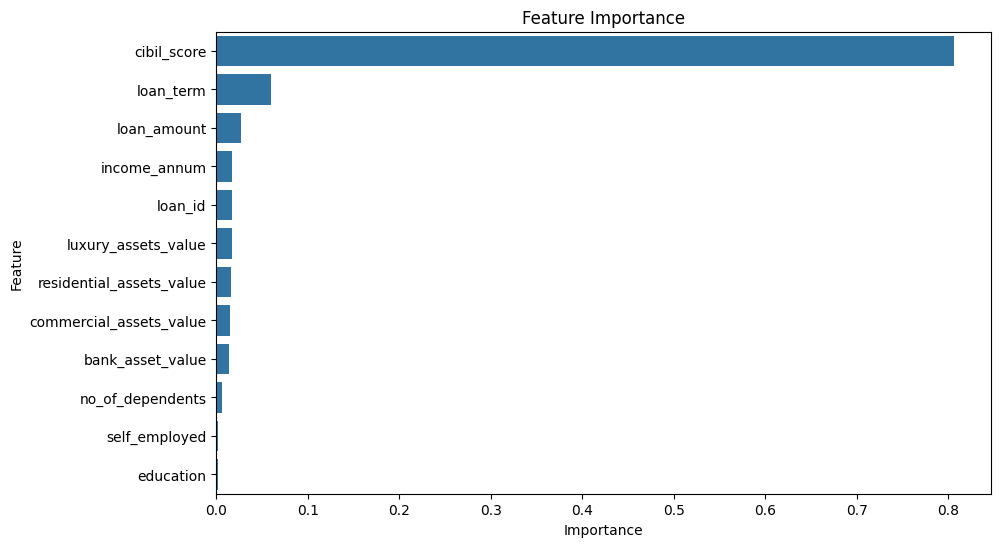

In [76]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance")


## Final Conclusion
The tuned Random Forest model achieved strong performance with stable cross-validation results.
Precision and recall analysis provided deeper insight into risk management.
Threshold tuning allows business-level control over approval strictness.
Feature importance highlights major financial indicators influencing approval decisions.
This system provides a scalable and data-driven approach for automated loan approval.

### Business Insight

- Higher income significantly increases approval probability.
- Higher loan amount relative to income increases rejection risk.
- Credit-related variables strongly influence model decisions.
- Threshold tuning allows financial institutions to adjust risk tolerance.
